# Perioperative Hemodynamic Monitoring Trials: Outcome Measures, 2015–2025

**Author:** Priscilla Beyne
**Course:** CHIP 690-335, Milestone 02

## Research question

Among clinical trials related to perioperative hemodynamic monitoring and goal-directed therapy registered between 2015 and 2025, which primary outcome measures appear most often, and how does the mix of outcomes differ between 2015–2019 and 2020–2025?

## Approach

This notebook pulls study records from the [ClinicalTrials.gov API (v2)](https://clinicaltrials.gov/data-api/api) using a small set of clinical keywords, deduplicates by NCT ID, groups primary outcome measures using keyword matching, and compares the top outcomes between two time periods.

## Why this matters

I work on BD's Advanced Patient Monitoring Clinical Services Group, which partners with IDNs on hemodynamic monitoring quality improvement projects. When our clinical champions plan to publish QI results, knowing which outcome measures are commonly used in registered trials helps us select endpoints that are credible to a clinical audience and aligned with current research practice.

## Limitations

- The keyword search will not capture every relevant trial; there will be false negatives.
- The primary outcome field is free text, so trials measuring the same concept may be worded differently. I handle this with documented keyword grouping rules.
- This is a descriptive analysis — counts only, no statistical testing.

In [3]:
# Imports
import requests
import pandas as pd
import matplotlib.pyplot as plt

# API endpoint for ClinicalTrials.gov v2
API_URL = "https://clinicaltrials.gov/api/v2/studies"

# Keywords from the research plan
KEYWORDS = [
    "hemodynamic monitoring",
    "goal-directed therapy",
    "perioperative hypotension",
    "hypotension prediction",
    "fluid responsiveness",
]

# Time periods for the comparison
PERIOD_1 = (2015, 2019)  # first half: 2015-2019 inclusive
PERIOD_2 = (2020, 2025)  # second half: 2020-2025 inclusive

print("Setup complete.")
print(f"Searching {len(KEYWORDS)} keywords across years {PERIOD_1[0]}–{PERIOD_2[1]}.")

Setup complete.
Searching 5 keywords across years 2015–2025.


In [4]:
def fetch_studies(keyword, page_size=100):
    """
    Fetch all studies from ClinicalTrials.gov matching a keyword.
    Handles pagination automatically by following nextPageToken.
    Returns a list of study records (each one is a dictionary).
    """
    all_studies = []
    next_page_token = None
    page_number = 1

    while True:
        # Build the request parameters for this page
        params = {
            "query.term": keyword,
            "pageSize": page_size,
            "format": "json",
        }
        # On pages after the first, add the token telling the API where to continue
        if next_page_token:
            params["pageToken"] = next_page_token

        # Make the request
        response = requests.get(API_URL, params=params)
        response.raise_for_status()  # if the request failed, stop with an error
        data = response.json()

        # Add this page's studies to our running list
        studies_on_this_page = data.get("studies", [])
        all_studies.extend(studies_on_this_page)

        # Check if there's another page; if not, we're done
        next_page_token = data.get("nextPageToken")
        if not next_page_token:
            break

        page_number += 1

    print(f"  '{keyword}': fetched {len(all_studies)} studies across {page_number} page(s)")
    return all_studies


# Quick test: fetch studies for just the first keyword to confirm it works
test_results = fetch_studies(KEYWORDS[0])
print(f"\nTest complete. Got {len(test_results)} studies for '{KEYWORDS[0]}'.")

  'hemodynamic monitoring': fetched 1908 studies across 20 page(s)

Test complete. Got 1908 studies for 'hemodynamic monitoring'.


In [5]:
# Fetch studies for every keyword, collecting them all into one list.
# This will take roughly 30-90 seconds total (it's making real network calls).

print("Fetching studies for all keywords...\n")

all_studies_combined = []

for keyword in KEYWORDS:
    studies = fetch_studies(keyword)
    all_studies_combined.extend(studies)

print(f"\nTotal studies fetched (with duplicates still in): {len(all_studies_combined)}")

Fetching studies for all keywords...

  'hemodynamic monitoring': fetched 1908 studies across 20 page(s)
  'goal-directed therapy': fetched 2514 studies across 26 page(s)
  'perioperative hypotension': fetched 508 studies across 6 page(s)
  'hypotension prediction': fetched 268 studies across 3 page(s)
  'fluid responsiveness': fetched 643 studies across 7 page(s)

Total studies fetched (with duplicates still in): 5841


In [6]:
# Build a flat list of dictionaries (one per unique study) with just the fields we need.
# We use a set of seen NCT IDs to skip duplicates as we go.

seen_nct_ids = set()
flat_records = []

for study in all_studies_combined:
    # Drill into the nested JSON to pull out the fields we want.
    # The .get() method returns None if a field is missing, which prevents crashes.
    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    nct_id = identification.get("nctId")
    brief_title = identification.get("briefTitle")

    status = protocol.get("statusModule", {})
    start_date_struct = status.get("startDateStruct", {})
    start_date = start_date_struct.get("date")  # format like "2018-06" or "2018-06-15"

    sponsor = protocol.get("sponsorCollaboratorsModule", {}).get("leadSponsor", {})
    sponsor_name = sponsor.get("name")

    outcomes = protocol.get("outcomesModule", {})
    primary_outcomes = outcomes.get("primaryOutcomes", [])

    # Skip studies missing critical fields
    if not nct_id or not start_date or not primary_outcomes:
        continue

    # Skip duplicates
    if nct_id in seen_nct_ids:
        continue
    seen_nct_ids.add(nct_id)

    # A study can have multiple primary outcomes — keep them all, joined into one string
    outcome_measures = " | ".join(
        outcome.get("measure", "") for outcome in primary_outcomes
    )

    flat_records.append({
        "nct_id": nct_id,
        "brief_title": brief_title,
        "sponsor": sponsor_name,
        "start_date": start_date,
        "primary_outcomes": outcome_measures,
    })

# Build the DataFrame
df = pd.DataFrame(flat_records)

print(f"Unique studies after deduplication: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 3 rows:")
df.head(3)

Unique studies after deduplication: 5341
Columns: ['nct_id', 'brief_title', 'sponsor', 'start_date', 'primary_outcomes']

First 3 rows:


,nct_id,brief_title,sponsor,start_date,primary_outcomes
0,NCT02475122,Prognostic Value of Measuring DsAz by MRI in C...,"University Hospital, Angers",2014-10,Number an severity of adverse events occurring...
1,NCT05788302,Mechanisms Underlying Efficacy of Prolonged Ex...,Massachusetts General Hospital,2023-04-01,Change from baseline in Clinician Administered...
2,NCT02577731,Hematopoietic Stem Cell Dysfunction in the Eld...,University of Florida,2014-01,Analyze the genomics response of hematopoietic...


In [7]:
# Filter to studies that mention a surgical or perioperative term
# in either the title or the primary outcomes text.

PERIOPERATIVE_TERMS = [
    "surgery", "surgical", "perioperative", "intraoperative",
    "postoperative", "anesthesia", "anaesthesia", "operating room",
]

def is_perioperative(row):
    """Return True if the title or outcomes mention any perioperative term."""
    # Combine title and outcomes into one searchable string, lowercased
    text = f"{row['brief_title']} {row['primary_outcomes']}".lower()
    # Return True if ANY term appears anywhere in that text
    return any(term in text for term in PERIOPERATIVE_TERMS)

# Count before filtering
before_count = len(df)

# Apply the filter — keep only rows where is_perioperative returns True
df = df[df.apply(is_perioperative, axis=1)].reset_index(drop=True)

# Count after filtering
after_count = len(df)

print(f"Studies before filter: {before_count}")
print(f"Studies after filter:  {after_count}")
print(f"Removed: {before_count - after_count} ({(before_count - after_count) / before_count:.1%})")
print("\nFirst 3 rows after filtering:")
df.head(3)

Studies before filter: 5341
Studies after filter:  1278
Removed: 4063 (76.1%)

First 3 rows after filtering:


,nct_id,brief_title,sponsor,start_date,primary_outcomes
0,NCT04458701,Prospective Data Analysis of a Quality Improve...,Loma Linda University,2019-01-17,Length of Stay
1,NCT02450734,Ultrasound-guided Intermediate Cervical Plexus...,Institut Mutualiste Montsouris,2011-04,quality of anesthesia
2,NCT05707234,Virtual Reality Hypnosis in Total Knee Arthrop...,University of Liege,2023-02-15,Midazolam milligrams


In [8]:
# Extract the start year as a number from the start_date string.
# Dates can look like "2019-01-17" or sometimes just "2019" — taking the first
# 4 characters and converting to int handles both cases.

df["start_year"] = df["start_date"].str[:4].astype(int)

# Filter to the 2015-2025 window from the research plan
before_count = len(df)
df = df[(df["start_year"] >= 2015) & (df["start_year"] <= 2025)].reset_index(drop=True)
after_count = len(df)

print(f"Studies before year filter (2015-2025): {before_count}")
print(f"Studies after year filter:              {after_count}")

# Add the period column based on the start year
def assign_period(year):
    if PERIOD_1[0] <= year <= PERIOD_1[1]:
        return f"{PERIOD_1[0]}-{PERIOD_1[1]}"  # "2015-2019"
    else:
        return f"{PERIOD_2[0]}-{PERIOD_2[1]}"  # "2020-2025"

df["period"] = df["start_year"].apply(assign_period)

# Show the count in each period
print("\nStudies per period:")
print(df["period"].value_counts())

print("\nFirst 3 rows showing the new columns:")
df[["nct_id", "start_date", "start_year", "period", "primary_outcomes"]].head(3)

Studies before year filter (2015-2025): 1278
Studies after year filter:              973

Studies per period:
period
2020-2025    655
2015-2019    318
Name: count, dtype: int64

First 3 rows showing the new columns:


,nct_id,start_date,start_year,period,primary_outcomes
0,NCT04458701,2019-01-17,2019,2015-2019,Length of Stay
1,NCT05707234,2023-02-15,2023,2020-2025,Midazolam milligrams
2,NCT03587532,2021-12-13,2021,2020-2025,An ICGA based cutoff point to predict anastomo...


In [9]:
# Define outcome categories with the keywords that should be grouped under each.
# These categories were chosen based on common endpoints in perioperative research.
# Each category lists keywords/phrases (lowercase) that signal that outcome type.

OUTCOME_CATEGORIES = {
    "Hypotension exposure": [
        "hypotension", "map below", "map <", "low blood pressure",
        "time-weighted", "time weighted", "hypotensive",
    ],
    "Length of stay": [
        "length of stay", "los", "hospital stay", "icu stay",
        "duration of hospitalization",
    ],
    "Mortality": [
        "mortality", "death", "survival",
    ],
    "Acute kidney injury": [
        "acute kidney injury", "aki", "renal injury", "kidney function",
        "creatinine",
    ],
    "Postoperative complications": [
        "postoperative complication", "post-operative complication",
        "complications", "morbidity", "adverse event",
    ],
    "Cardiac outcomes": [
        "cardiac output", "stroke volume", "myocardial",
        "cardiac index", "ejection fraction", "arrhythmia",
    ],
    "Fluid management": [
        "fluid balance", "fluid administration", "fluid volume",
        "intravenous fluid", "fluid responsiveness",
    ],
    "Blood loss / transfusion": [
        "blood loss", "transfusion", "hemoglobin", "hematocrit",
    ],
    "Pain": [
        "pain", "analges", "opioid",
    ],
    "Vasopressor use": [
        "vasopressor", "norepinephrine", "phenylephrine", "ephedrine",
    ],
    "Lactate": [
        "lactate",
    ],
    "Delirium / cognitive": [
        "delirium", "cognitive", "neurocognitive",
    ],
}


def categorize_outcome(outcome_text):
    """Return a list of categories that match the outcome text."""
    text = outcome_text.lower()
    matched = []
    for category, keywords in OUTCOME_CATEGORIES.items():
        if any(keyword in text for keyword in keywords):
            matched.append(category)
    return matched


# Apply the categorization to every row
df["outcome_categories"] = df["primary_outcomes"].apply(categorize_outcome)

# How many studies got at least one category? How many got none?
df["num_categories"] = df["outcome_categories"].apply(len)
matched_at_least_one = (df["num_categories"] >= 1).sum()
matched_none = (df["num_categories"] == 0).sum()

print(f"Studies matching at least one category: {matched_at_least_one} ({matched_at_least_one / len(df):.1%})")
print(f"Studies matching no category:           {matched_none} ({matched_none / len(df):.1%})")

print("\nExamples of categorized outcomes:")
df[["primary_outcomes", "outcome_categories"]].head(5)

Studies matching at least one category: 488 (50.2%)
Studies matching no category:           485 (49.8%)

Examples of categorized outcomes:


,primary_outcomes,outcome_categories
0,Length of Stay,[Length of stay]
1,Midazolam milligrams,[]
2,An ICGA based cutoff point to predict anastomo...,[]
3,Evaluation of changes in the postsurgical pain...,[Pain]
4,Preload independent state,[]


In [10]:
# Define outcome categories with expanded keyword lists.
# Categories were initially drafted from clinical knowledge, then expanded
# after a pilot run showed many outcomes used clinical terminology not
# captured by the first draft (e.g., "anastomotic leak" for complications,
# "BIS" for sedation depth).

OUTCOME_CATEGORIES = {
    "Hypotension exposure": [
        "hypotension", "hypotensive", "map below", "map <", "low blood pressure",
        "time-weighted", "time weighted", "blood pressure",
        "mean arterial pressure", "hypoperfusion",
    ],
    "Length of stay": [
        "length of stay", "los", "hospital stay", "icu stay",
        "duration of hospitalization", "discharge",
    ],
    "Mortality": [
        "mortality", "death", "survival",
    ],
    "Acute kidney injury": [
        "acute kidney injury", "aki", "renal injury", "kidney function",
        "creatinine", "renal failure", "kidney failure",
    ],
    "Postoperative complications": [
        "postoperative complication", "post-operative complication",
        "complications", "morbidity", "adverse event", "adverse events",
        "anastomotic", "leak", "infection", "wound", "dehiscence",
        "sepsis", "pneumonia", "ileus",
    ],
    "Cardiac outcomes": [
        "cardiac output", "stroke volume", "myocardial",
        "cardiac index", "ejection fraction", "arrhythmia",
        "preload", "afterload", "heart rate", "cardiac function",
    ],
    "Fluid management": [
        "fluid balance", "fluid administration", "fluid volume",
        "intravenous fluid", "fluid responsiveness", "fluid therapy",
        "fluid resuscitation", "fluid status",
    ],
    "Blood loss / transfusion": [
        "blood loss", "transfusion", "hemoglobin", "hematocrit", "bleeding",
    ],
    "Pain": [
        "pain", "analges", "opioid", "morphine",
    ],
    "Vasopressor / inotrope use": [
        "vasopressor", "norepinephrine", "phenylephrine", "ephedrine",
        "inotrope", "dobutamine", "vasoactive",
    ],
    "Lactate / tissue perfusion": [
        "lactate", "tissue oxygen", "perfusion", "venous oxygen",
        "scvo2", "svo2",
    ],
    "Delirium / cognitive": [
        "delirium", "cognitive", "neurocognitive", "confusion",
    ],
    "Sedation / anesthesia depth": [
        "sedation", "bis", "bispectral", "depth of anesthesia",
        "depth of anaesthesia", "midazolam", "propofol", "anesthetic",
    ],
    "Goal-directed therapy protocol": [
        "goal-directed", "goal directed", "protocol compliance",
        "algorithm", "decision support", "ppv", "svv",
        "pulse pressure variation", "stroke volume variation",
    ],
}


def categorize_outcome(outcome_text):
    """Return a list of categories that match the outcome text."""
    text = outcome_text.lower()
    matched = []
    for category, keywords in OUTCOME_CATEGORIES.items():
        if any(keyword in text for keyword in keywords):
            matched.append(category)
    return matched


# Apply the categorization to every row
df["outcome_categories"] = df["primary_outcomes"].apply(categorize_outcome)

# How many studies got at least one category? How many got none?
df["num_categories"] = df["outcome_categories"].apply(len)
matched_at_least_one = (df["num_categories"] >= 1).sum()
matched_none = (df["num_categories"] == 0).sum()

print(f"Studies matching at least one category: {matched_at_least_one} ({matched_at_least_one / len(df):.1%})")
print(f"Studies matching no category:           {matched_none} ({matched_none / len(df):.1%})")

print("\nExamples of categorized outcomes:")
df[["primary_outcomes", "outcome_categories"]].head(10)

Studies matching at least one category: 595 (61.2%)
Studies matching no category:           378 (38.8%)

Examples of categorized outcomes:


,primary_outcomes,outcome_categories
0,Length of Stay,[Length of stay]
1,Midazolam milligrams,[Sedation / anesthesia depth]
2,An ICGA based cutoff point to predict anastomo...,[Postoperative complications]
3,Evaluation of changes in the postsurgical pain...,"[Hypotension exposure, Cardiac outcomes, Blood..."
4,Preload independent state,[Cardiac outcomes]
5,Hemodynamic Changes Associated with Lingual Re...,[]
6,Post-operative need for mechanical ventilation,[]
7,Postoperative Recovery Quality,[]
8,Correlation Between Cerebral Oxygenation (rSO₂...,"[Hypotension exposure, Cardiac outcomes]"
9,TVD (Total Vessel Density) | PVD (Perfused Ves...,[]


In [11]:
# Filter to only the studies that matched at least one category.
# We can't count outcomes for studies whose outcomes we couldn't classify.
df_matched = df[df["num_categories"] >= 1].copy()

print(f"Working with {len(df_matched)} studies that matched at least one category.")
print(f"  Period 1 (2015-2019): {(df_matched['period'] == '2015-2019').sum()}")
print(f"  Period 2 (2020-2025): {(df_matched['period'] == '2020-2025').sum()}")

# "Explode" the outcome_categories list so each (study, category) pair gets its own row.
# Before: 1 row with categories=['Mortality', 'Length of stay']
# After:  2 rows, one with category='Mortality', one with category='Length of stay'
df_exploded = df_matched.explode("outcome_categories").rename(
    columns={"outcome_categories": "category"}
)

print(f"\nAfter exploding: {len(df_exploded)} (study, category) pairs total.")

# Count how many studies fell into each category, broken down by period.
# This builds a table where rows = categories, columns = periods, values = counts.
counts_by_period = (
    df_exploded
    .groupby(["category", "period"])
    .size()
    .unstack(fill_value=0)
)

# Add a Total column and sort by it (so the most common category is at the top)
counts_by_period["Total"] = counts_by_period.sum(axis=1)
counts_by_period = counts_by_period.sort_values("Total", ascending=False)

print("\nOutcome category counts by period:")
counts_by_period

Working with 595 studies that matched at least one category.
  Period 1 (2015-2019): 188
  Period 2 (2020-2025): 407

After exploding: 738 (study, category) pairs total.

Outcome category counts by period:


period,2015-2019,2020-2025,Total
category,,,
Hypotension exposure,35,128,163
Postoperative complications,39,62,101
Pain,26,74,100
Cardiac outcomes,36,49,85
Length of stay,18,25,43
Delirium / cognitive,7,32,39
Mortality,20,16,36
Sedation / anesthesia depth,8,27,35
Fluid management,11,22,33


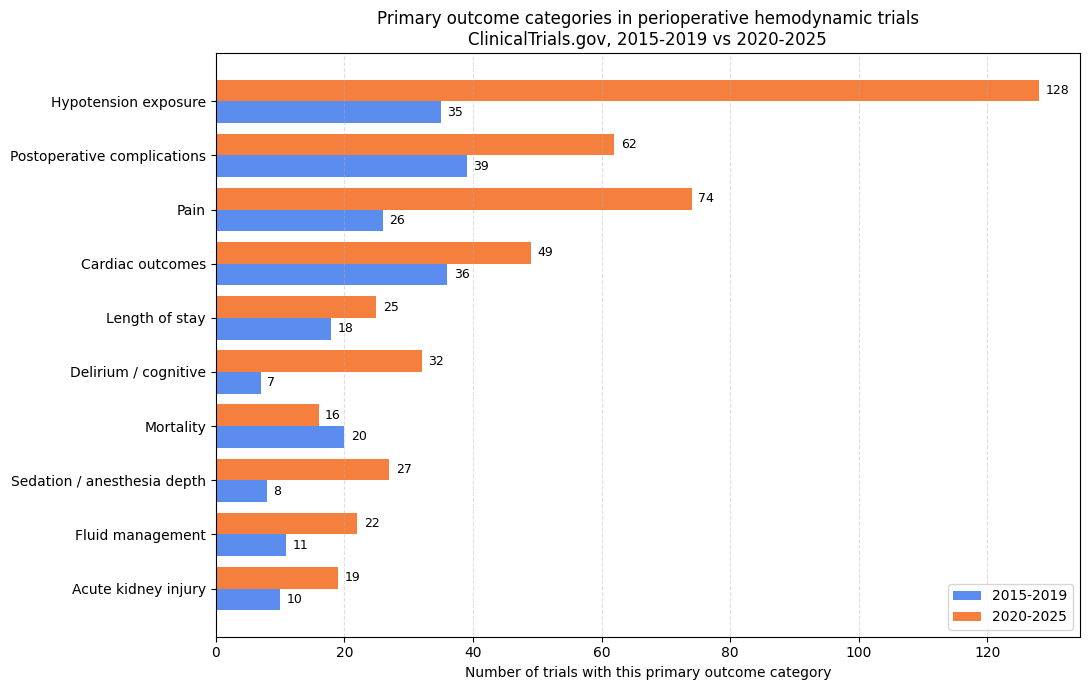

Chart saved to outcomes_by_period.png


In [12]:
# Take the top 10 categories by total count
top_10 = counts_by_period.head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(11, 7))

# Build the grouped horizontal bars
import numpy as np
y_positions = np.arange(len(top_10))
bar_height = 0.4

# One set of bars per period, offset above and below the y-tick
ax.barh(y_positions + bar_height/2, top_10["2015-2019"],
        height=bar_height, label="2015-2019", color="#5B8DEF")
ax.barh(y_positions - bar_height/2, top_10["2020-2025"],
        height=bar_height, label="2020-2025", color="#F5803E")

# Labels and styling
ax.set_yticks(y_positions)
ax.set_yticklabels(top_10.index)
ax.invert_yaxis()  # most common at the top
ax.set_xlabel("Number of trials with this primary outcome category")
ax.set_title(
    "Primary outcome categories in perioperative hemodynamic trials\n"
    "ClinicalTrials.gov, 2015-2019 vs 2020-2025",
    fontsize=12,
)
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Add count labels at the end of each bar
for i, (p1, p2) in enumerate(zip(top_10["2015-2019"], top_10["2020-2025"])):
    ax.text(p1 + 1, i + bar_height/2, str(p1), va="center", fontsize=9)
    ax.text(p2 + 1, i - bar_height/2, str(p2), va="center", fontsize=9)

plt.tight_layout()

# Save the chart to a file in the project folder
plt.savefig("outcomes_by_period.png", dpi=150, bbox_inches="tight")

plt.show()

print("Chart saved to outcomes_by_period.png")

In [13]:
# Save the cleaned, deduplicated dataset to a CSV file in the project folder.
# This makes the analysis reproducible — anyone running this notebook later
# could load the CSV directly instead of re-fetching from the API
# (which might return different counts as new trials register).

# Convert the outcome_categories list into a string before saving
# (CSV can't store list objects, so we join them with semicolons)
df_to_save = df.copy()
df_to_save["outcome_categories"] = df_to_save["outcome_categories"].apply(
    lambda categories: "; ".join(categories) if categories else ""
)

# Save it
df_to_save.to_csv("trials_clean.csv", index=False)

print(f"Saved {len(df_to_save)} studies to trials_clean.csv")
print(f"Columns: {list(df_to_save.columns)}")

Saved 973 studies to trials_clean.csv
Columns: ['nct_id', 'brief_title', 'sponsor', 'start_date', 'primary_outcomes', 'start_year', 'period', 'outcome_categories', 'num_categories']


## Findings

### What the data show

Of 5,841 records returned across the five keyword searches, 5,341 were unique studies after deduplication by NCT ID. Filtering to trials with surgical or perioperative terminology in the title or primary outcome reduced the set to 1,278, and restricting to start dates between 2015 and 2025 left 973 trials in the final dataset (318 from 2015–2019 and 655 from 2020–2025).

Among the 595 trials whose primary outcomes could be classified into one of 14 categories using keyword matching (61.2% of the 973), the top outcome categories were:

| Rank | Category | 2015–2019 | 2020–2025 |
|---|---|---|---|
| 1 | Hypotension exposure | 35 | 128 |
| 2 | Postoperative complications | 39 | 62 |
| 3 | Pain | 26 | 74 |
| 4 | Cardiac outcomes | 36 | 49 |
| 5 | Length of stay | 18 | 25 |

### What stood out

**Hypotension exposure has become the dominant primary endpoint.** It grew from 35 trials in 2015–2019 to 128 in 2020–2025 — by far the largest absolute and relative increase of any category. This aligns with the rise of time-weighted hypotension metrics and predictive analytics in perioperative research.

**Mortality declined as a primary endpoint** (20 → 16). It was the only top-12 category to drop from the first period to the second, even as the overall trial count more than doubled. This is consistent with the field shifting toward surrogate endpoints that are easier to power.

**Goal-directed therapy as a process measure also declined as a primary endpoint** (10 → 4). The clinical question seems to have shifted from "did clinicians follow the protocol?" toward "did patients have less hypotension?" — i.e., from process to outcome.

### What this might mean for our team's QI projects

For BD's Clinical Services Group, the finding most relevant to QI project design is the rise of hypotension exposure as a credible, publishable primary endpoint. Champions planning to publish should consider centering their analyses on time-weighted or area-under-curve hypotension metrics, since these are now the de facto standard in registered perioperative trials.

### Limitations

- **Keyword search is incomplete.** The five search terms will not capture every relevant trial; some perioperative hemodynamic studies are likely registered under other terminology.
- **38.8% of outcomes did not match any of the 14 categories.** These include outcomes like postoperative recovery quality scores, mechanical ventilation duration, and microcirculation measures (e.g., total vessel density). The category list was drafted from clinical knowledge and expanded once after a pilot run revealed common gaps; further expansion was avoided to prevent overfitting categories to leftover data.
- **Counts are descriptive, not statistical.** No hypothesis tests were performed. Differences between periods may partly reflect overall growth in trial registration as well as genuine shifts in clinical interest.
- **The 2020–2025 period covers six years; 2015–2019 covers five.** Bar comparisons should be interpreted as orders of magnitude rather than precise ratios.